# 3. Búsqueda de hilos similares

Similitud de documentos con sentence embeddings de FastText y de varios modelos de sentence-transformers, visualización 2D (PCA + t-SNE) y mapas de calor.

In [ ]:
from pathlib import Path

# Carpeta donde viven todos los .json del corpus (ver ../scripts/00_descarga_datos.py)
DATA_DIR = Path('../data')
assert DATA_DIR.exists(), "No se encuentra la carpeta data/ ¿ejecutaste desde notebooks/?"

## **3- Búsqueda de hilos similares**

### 3.1- Instalaciones y carga del modelo FastText preentrenado en inglés.

In [ ]:
!pip3 install fasttext
import fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 4.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653907 sha256=66f1f9057e0c957e7ef41f7aaf0868d6e099c2741ce87d5b4e52794d6056e7df
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


Dado que no se especificaba un modelo concreto a utilizar, optamos por emplear el modelo cc.en.300.bin. Este modelo corresponde a una versión preentrenada de FastText para inglés, basada en vectores de palabras de 300 dimensiones y entrenada sobre grandes corpus de texto

In [ ]:
import fasttext.util

# Esto descargará el modelo de inglés y lo comprimirá para que ocupe menos espacio
# fasttext.util.download_model('en', if_exists='ignore') ##ESTA LÍNEA YA NO ES NECESARIA QUE LA EJECUTE PORQUE YA LO GUARDÉ EN DRIVE
ft_model_en = fasttext.load_model('../data/cc.en.300.bin')

La siguiente celda se encuentra comentada porque de igual forma que comentamos una línea de la celda anterior, una vez que descargamos dicho modelo en la sesión de colab, lo pasamos a Drive, y ya cada vez que íbamos ejecutando el notebook, lo cargábamos desde Drive, para ir más rápido.

In [ ]:
# from google.colab import drive
# import shutil
# import os

# # 2. Definir rutas
# ruta_origen = 'cc.en.300.bin'
# ruta_destino = '../data/cc.en.300.bin'

# # 3. Mover o copiar el archivo
# if not os.path.exists(ruta_destino):
#     print("Copiando modelo a Drive... esto puede tardar unos minutos.")
#     shutil.copy(ruta_origen, ruta_destino)
#     print("¡Guardado!")

### 3.2- Carga de los JSON y construcción del texto por hilo (concatenación de comentarios). Aquí generamos un DataFrame con columnas submission_id, subreddit, titulo, texto_final.

In [ ]:
import json
import pandas as pd
from pathlib import Path

SUBREDDITS = ["Python", "Chemistry", "Investing", "Soccer", "Cooking", "Autism"]
BASE_PATH = Path('../data/')

datos_hilos = []

for sub_name in SUBREDDITS:
    file_path = BASE_PATH / f"{sub_name}_filtrado.json"

    if not file_path.exists():
        print(f"No se encontró el archivo para {sub_name}")
        continue

    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    for sub in data['submissions']:
        # 1. Extraemos el título y la descripción (selftext)
        titulo = sub.get('title', '')
        descripcion = sub.get('selftext', '')

        # 2. Concatenamos todos los cuerpos de los comentarios
        comentarios_texto = " ".join([c.get('body', '') for c in sub.get('comments', [])])

        # 3. Creamos el "Documento" completo del hilo
        # Unimos Título + Descripción + Comentarios
        texto_completo = f"{titulo} {descripcion} {comentarios_texto}"

        # 4. Guardamos la info relevante
        datos_hilos.append({
            'id': sub.get('id'),
            'subreddit': sub_name,
            'titulo': titulo,
            'texto_final': texto_completo
        })

# Creamos el DataFrame
df_hilos = pd.DataFrame(datos_hilos)

print(f"Corpus preparado: {len(df_hilos)} hilos listos para procesar.")
df_hilos[['subreddit', 'titulo', 'texto_final']].head()

Corpus preparado: 240 hilos listos para procesar.


,subreddit,titulo,texto_final
0,Python,For those that use Python in their job: Do you...,For those that use Python in their job: Do you...
1,Python,TIL: `uv pip install` doesn't compile bytecode...,TIL: `uv pip install` doesn't compile bytecode...
2,Python,The creators of ruff and uv are building a new...,The creators of ruff and uv are building a new...
3,Python,A new type of interpreter has been added to Py...,A new type of interpreter has been added to Py...
4,Python,Is UV package manager taking over?,Is UV package manager taking over? Hi!\nI am a...


### 3.3- Cálculo de sentence embeddings con FastText para cada hilo.

In [ ]:
import numpy as np

# 1. Limpiamos los saltos de línea (\n) y retornos de carro (\r)
# También nos aseguramos de que no haya valores nulos convirtiendo a string
df_hilos['texto_final'] = df_hilos['texto_final'].astype(str).str.replace(r'\n|\r', ' ', regex=True)

# 2. Aplicamos el modelo
# Usamos un lambda que por seguridad vuelve a limpiar espacios extra
df_hilos['embedding'] = df_hilos['texto_final'].apply(lambda x: ft_model_en.get_sentence_vector(x.strip()))

# 3. Convertimos la columna en una matriz de NumPy
X_embeddings = np.stack(df_hilos['embedding'].values)

print(f"Proceso finalizado.")
print(f"Dimensiones de la matriz de embeddings: {X_embeddings.shape}")

Proceso finalizado.
Dimensiones de la matriz de embeddings: (240, 300)


### 3.4- Matriz de similitud del coseno entre todos los hilos + heatmap

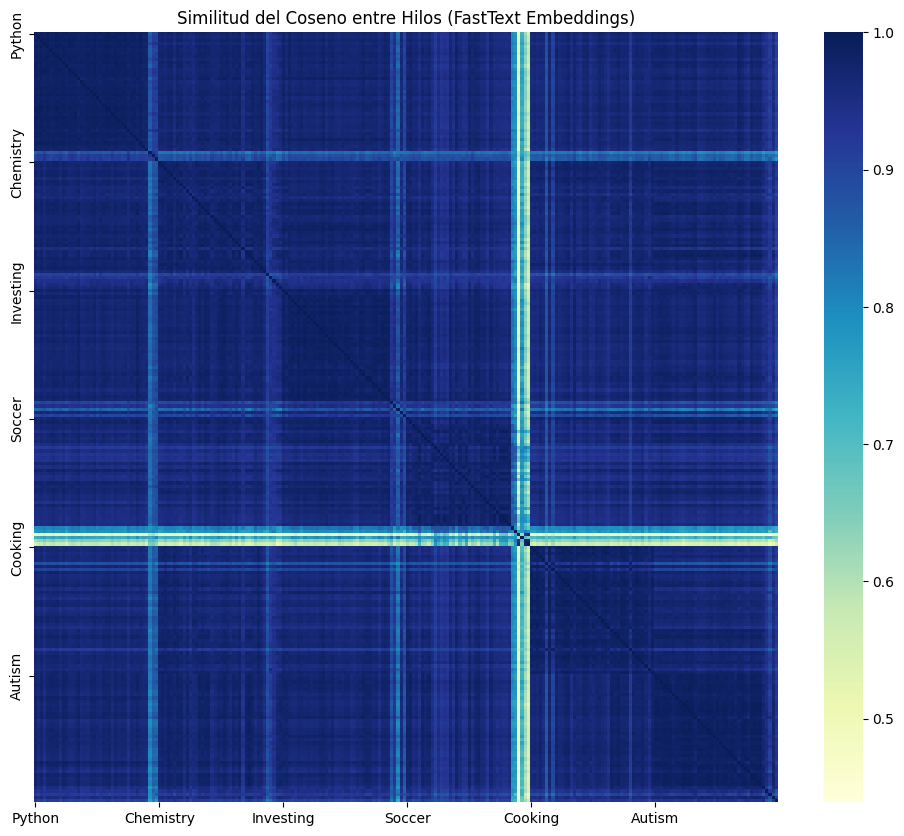

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la matriz de similitud (N x N)
# Usamos la matriz X_embeddings de la celda anterior
sim_matrix = cosine_similarity(X_embeddings)

# 2. Creamos un DataFrame para que el heatmap tenga etiquetas
# Usamos la columna 'subreddit' para identificar los ejes
labels = df_hilos['subreddit'].values
df_sim = pd.DataFrame(sim_matrix, index=labels, columns=labels)

# 3. Dibujamos el Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_sim,
            cmap='YlGnBu',
            xticklabels=40, # Mostramos una etiqueta cada 40 hilos para no amontonar
            yticklabels=40)

plt.title('Similitud del Coseno entre Hilos (FastText Embeddings)')
plt.show()

### 3.5- Encontrar los N hilos más similares a uno dado (búsqueda de vecinos más cercanos).

In [ ]:
def find_similar_threads(thread_id, n=5):
    """
    Busca los hilos más similares a uno dado usando la matriz de similitud calculada.
    """
    # 1. Encontrar el índice del hilo buscado
    if thread_id not in df_hilos['id'].values:
        print(f"El ID {thread_id} no existe en el DataFrame.")
        return

    idx = df_hilos[df_hilos['id'] == thread_id].index[0]

    # 2. Obtener las similitudes de ese hilo con todos los demás (fila de la matriz)
    similarities = sim_matrix[idx]

    # 3. Obtener los índices de los hilos más similares (excluyendo el propio hilo)
    # argsort ordena de menor a mayor, por eso usamos [-(n+1):-1] y le damos la vuelta [::-1]
    similar_indices = similarities.argsort()[-(n+1):-1][::-1]

    target_info = df_hilos.iloc[idx]
    print(f"Hilo objetivo: '{target_info['titulo']}' (Subreddit: r/{target_info['subreddit']})")
    print("-" * 80)
    print(f"{'Similitud':<10} | {'Subreddit':<12} | {'Título del hilo similar'}")
    print("-" * 80)

    for i in similar_indices:
        score = similarities[i]
        sim_info = df_hilos.iloc[i]
        print(f"{score:.4f}    | r/{sim_info['subreddit']:<10} | {sim_info['titulo'][:60]}...")

# Ejemplo de uso: Buscamos similares para el primer hilo del DataFrame
primer_id = df_hilos.iloc[0]['id']
find_similar_threads(primer_id, n=5)

Hilo objetivo: 'For those that use Python in their job: Do you like Python?' (Subreddit: r/Python)
--------------------------------------------------------------------------------
Similitud  | Subreddit    | Título del hilo similar
--------------------------------------------------------------------------------
0.9940    | r/Python     | What is a Python thing you slept on too long?...
0.9933    | r/Python     | uv starting to overtake Poetry in package download...
0.9924    | r/Python     | The creators of ruff and uv are building a new static type c...
0.9923    | r/Python     | Is UV package manager taking over?...
0.9921    | r/Python     | Stop building UI frameworks in Python...


### 3.6- Visualización 2D con PCA + t-SNE, puntos coloreados por subreddit.

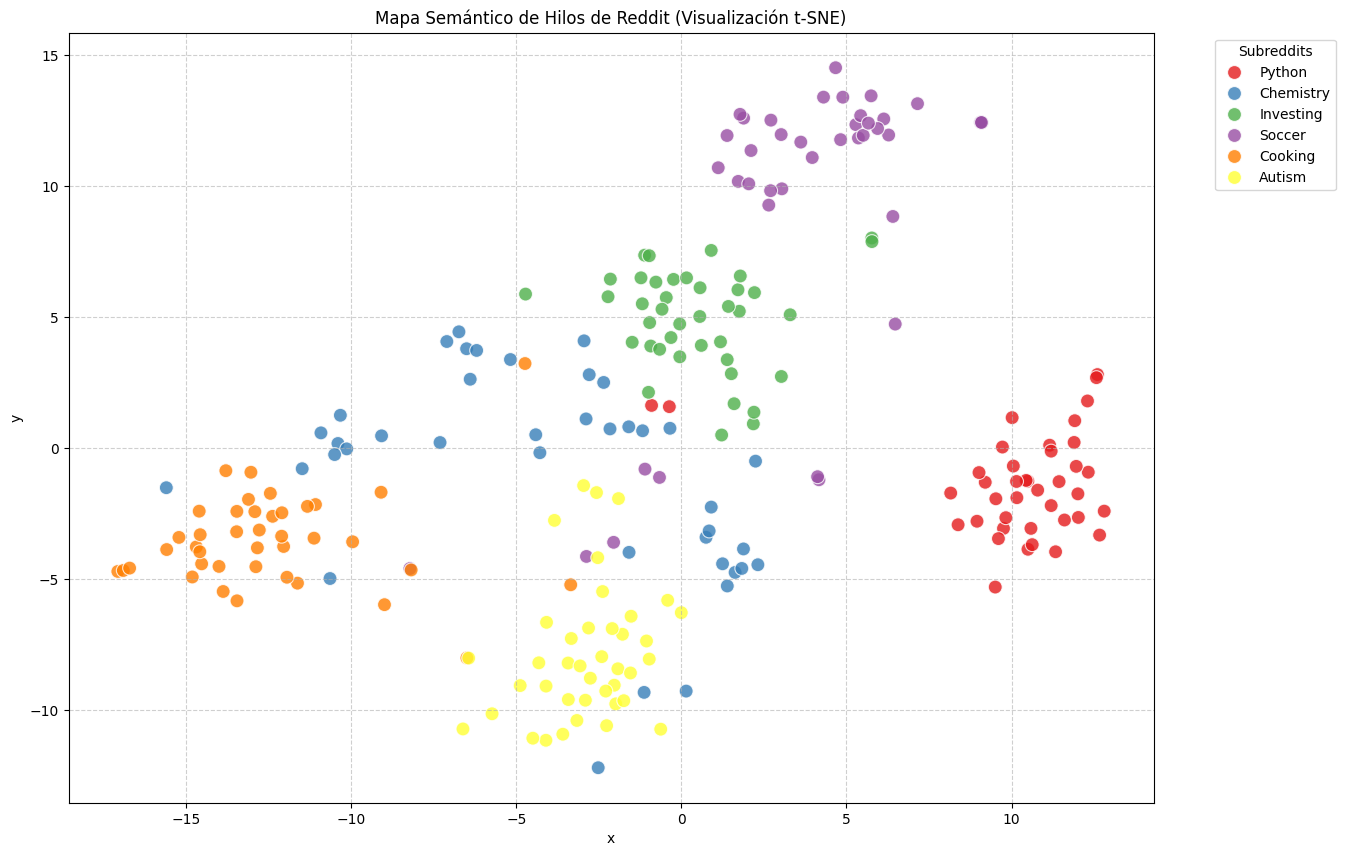

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PCA: Reducción lineal inicial para filtrar ruido
# Reducimos de 300D a 50D
n_samples = X_embeddings.shape[0]
pca = PCA(n_components=50, random_state=42)
pca_result = pca.fit_transform(X_embeddings)

# 2. t-SNE: Reducción no lineal para detectar clústeres
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
tsne_result = tsne.fit_transform(pca_result)

# 3. Crear DataFrame para el gráfico
df_vis = pd.DataFrame({
    'x': tsne_result[:, 0],
    'y': tsne_result[:, 1],
    'subreddit': df_hilos['subreddit'],
    'titulo': df_hilos['titulo']
})

# 4. Gráfico de dispersión
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_vis,
    x='x', y='y',
    hue='subreddit',
    palette='Set1',
    s=100,
    alpha=0.8,
    edgecolor='w'
)

plt.title('Mapa Semántico de Hilos de Reddit (Visualización t-SNE)')
plt.legend(title='Subreddits', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Hemos seguido la estrategia del Notebook 7.1(7_1_Word_embeddings_con_gensim_y_fasttext.ipynb, apartado 1.7), la cual consiste en primero aplicar PCA para reducir el ruido y las dimensiones iniciales, y luego t-SNE para crear los clústeres definidos por "subreddit" para detectar/identificar los hilos outliers/atípicos de cada subreddit.

### 3.7- Repetir pasos 3-6 con 2 sentence-transformers y comparación cualitativa.

#### 3.7.1- Instalación y carga de modelos Sentence-Transformers

Modelos Sentence-Transformers escogidos:
- https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2  
- https://huggingface.co/sentence-transformers/paraphrase-multilingual-mpnet-base-v2


Instalamos la librería necesaria y cargamos los dos modelos de Hugging Face. El modelo mpnet es más pesado pero suele ofrecer una precisión semántica superior.

In [ ]:
!pip install -U sentence-transformers
from sentence_transformers import SentenceTransformer

# Cargamos los dos modelos seleccionados
print("Cargando modelos de Hugging Face...")
model_mini = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
model_mpnet = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')

print("Modelos listos.")

Cargando modelos de Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelos listos.


#### 3.7.2- Generación de Embeddings (Transformers)

A diferencia de FastText, que hace una media de palabras, estos modelos procesan el contexto global de la frase.

In [ ]:
# El método encode maneja internamente la tokenización y el pooling
# Es importante pasar la columna como una lista
textos_a_procesar = df_hilos['texto_final'].tolist()

# Generamos las dos nuevas matrices de embeddings
X_emb_mini = model_mini.encode(textos_a_procesar, show_progress_bar=True)
X_emb_mpnet = model_mpnet.encode(textos_a_procesar, show_progress_bar=True)

print(f"Proceso finalizado.")
print(f"Dimensiones MiniLM (384d): {X_emb_mini.shape}")
print(f"Dimensiones MPNet (768d): {X_emb_mpnet.shape}")

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Proceso finalizado.
Dimensiones MiniLM (384d): (240, 384)
Dimensiones MPNet (768d): (240, 768)


#### 3.7.3- Cálculo de Similitudes y Comparación Visual (Heatmaps)

Calculamos las matrices de similitud del coseno para ambos modelos. La fórmula sigue siendo la misma que en FastText, pero sobre espacios vectoriales más densos.

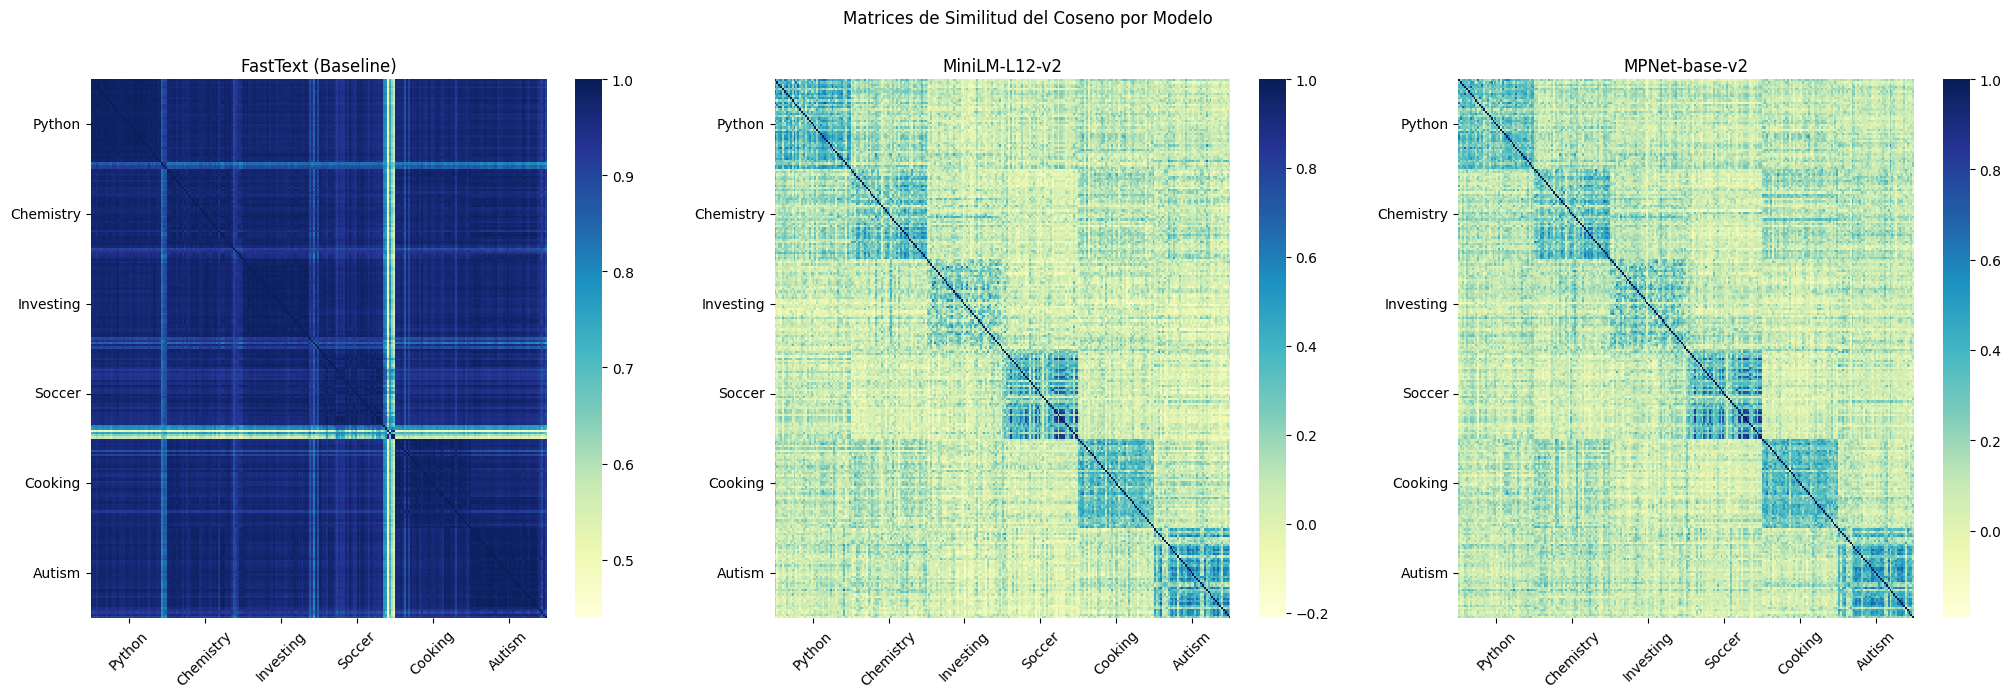

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculamos las nuevas matrices
sim_mini = cosine_similarity(X_emb_mini)
sim_mpnet = cosine_similarity(X_emb_mpnet)

def plot_enhanced_heatmap(matrix, title, ax):
    # Etiquetas de los subreddits para los ejes
    labels = df_hilos['subreddit'].values

    # Creamos el mapa de calor
    sns.heatmap(matrix, cmap='YlGnBu', ax=ax)

    # Configuramos los tics para que muestren el nombre del subreddit
    # en el centro de su bloque de 40 hilos
    tick_positions = [20, 60, 100, 140, 180, 220]
    tick_labels = SUBREDDITS

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels, rotation=0)

    ax.set_title(title)

# Ejecución de la comparativa visual
fig, axes = plt.subplots(1, 3, figsize=(25, 7))

plot_enhanced_heatmap(sim_matrix, "FastText (Baseline)", axes[0])
plot_enhanced_heatmap(sim_mini, "MiniLM-L12-v2", axes[1])
plot_enhanced_heatmap(sim_mpnet, "MPNet-base-v2", axes[2])

plt.suptitle('Matrices de Similitud del Coseno por Modelo')
plt.show()

Pese a que realizamos esta misma visualización para el modelo de FastText, la volvemos a mostrar junto a la de los otros dos modelos para poder compararla de mejor forma.

#### 3.7.4- Función de Búsqueda Comparativa


In [ ]:
def compare_similar_threads(thread_id, matrix, matrix_name, n=3):
    if thread_id not in df_hilos['id'].values: return

    idx = df_hilos[df_hilos['id'] == thread_id].index[0]
    similarities = matrix[idx]
    similar_indices = similarities.argsort()[-(n+1):-1][::-1]

    print(f"\n [Modelo: {matrix_name}] Similares a: '{df_hilos.iloc[idx]['titulo'][:50]}...'")
    for i in similar_indices:
        print(f"   - ({similarities[i]:.4f}) [r/{df_hilos.iloc[i]['subreddit']}] {df_hilos.iloc[i]['titulo'][:60]}")

# Ejemplo de uso con un hilo cualquiera
target_id = df_hilos.iloc[0]['id']
compare_similar_threads(target_id, sim_matrix, "FastText")
compare_similar_threads(target_id, sim_mini, "MiniLM")
compare_similar_threads(target_id, sim_mpnet, "MPNet")


 [Modelo: FastText] Similares a: 'For those that use Python in their job: Do you lik...'
   - (0.9940) [r/Python] What is a Python thing you slept on too long?
   - (0.9933) [r/Python] uv starting to overtake Poetry in package download
   - (0.9924) [r/Python] The creators of ruff and uv are building a new static type c

 [Modelo: MiniLM] Similares a: 'For those that use Python in their job: Do you lik...'
   - (0.7704) [r/Python] Does is actually matter that Python is a simple language?
   - (0.6720) [r/Python] Python feels easy… until it doesn’t. What was your first rea
   - (0.6540) [r/Python] Whats your favorite Python trick or lesser known feature?

 [Modelo: MPNet] Similares a: 'For those that use Python in their job: Do you lik...'
   - (0.6867) [r/Python] Does is actually matter that Python is a simple language?
   - (0.6187) [r/Python] Whats your favorite Python trick or lesser known feature?
   - (0.5945) [r/Python] Python feels easy… until it doesn’t. What was your first re

Analizando las salidas anteriores, desde las matrices de similitud con mapas de calor, hasta los hilos más similares, razonamos, que FastText da puntuaciones altísimas (0.99) mientras que los Transformers son más "conservadores" (0.60 - 0.70), debido a que FastText al promediar vectores, las representaciones resultantes tienden a colapsar en un área similar del espacio vectorial.
Además, si los hilos comparten muchas palabras funcionales o términos de Reddit, la similitud matemática se dispara aunque el sentido profundo varíe.

Por otro lado los Transformers operan en un espacio de mayor dimensionalidad y son mucho más discriminativos. Una similitud de 0.68 en MPNet indica una relación semántica muy fuerte; el modelo es capaz de detectar matices que "penalizan" la puntuación si el contexto no es idéntico, lo que lo hace más preciso y menos propenso a falsos positivos.

Esto evidencia también los mapas de calor, por eso en el del modelo de FastText se ven casi todos los hilos muy similares(azul oscuro).



#### 3.7.5- Visualización Final (t-SNE Comparativo)

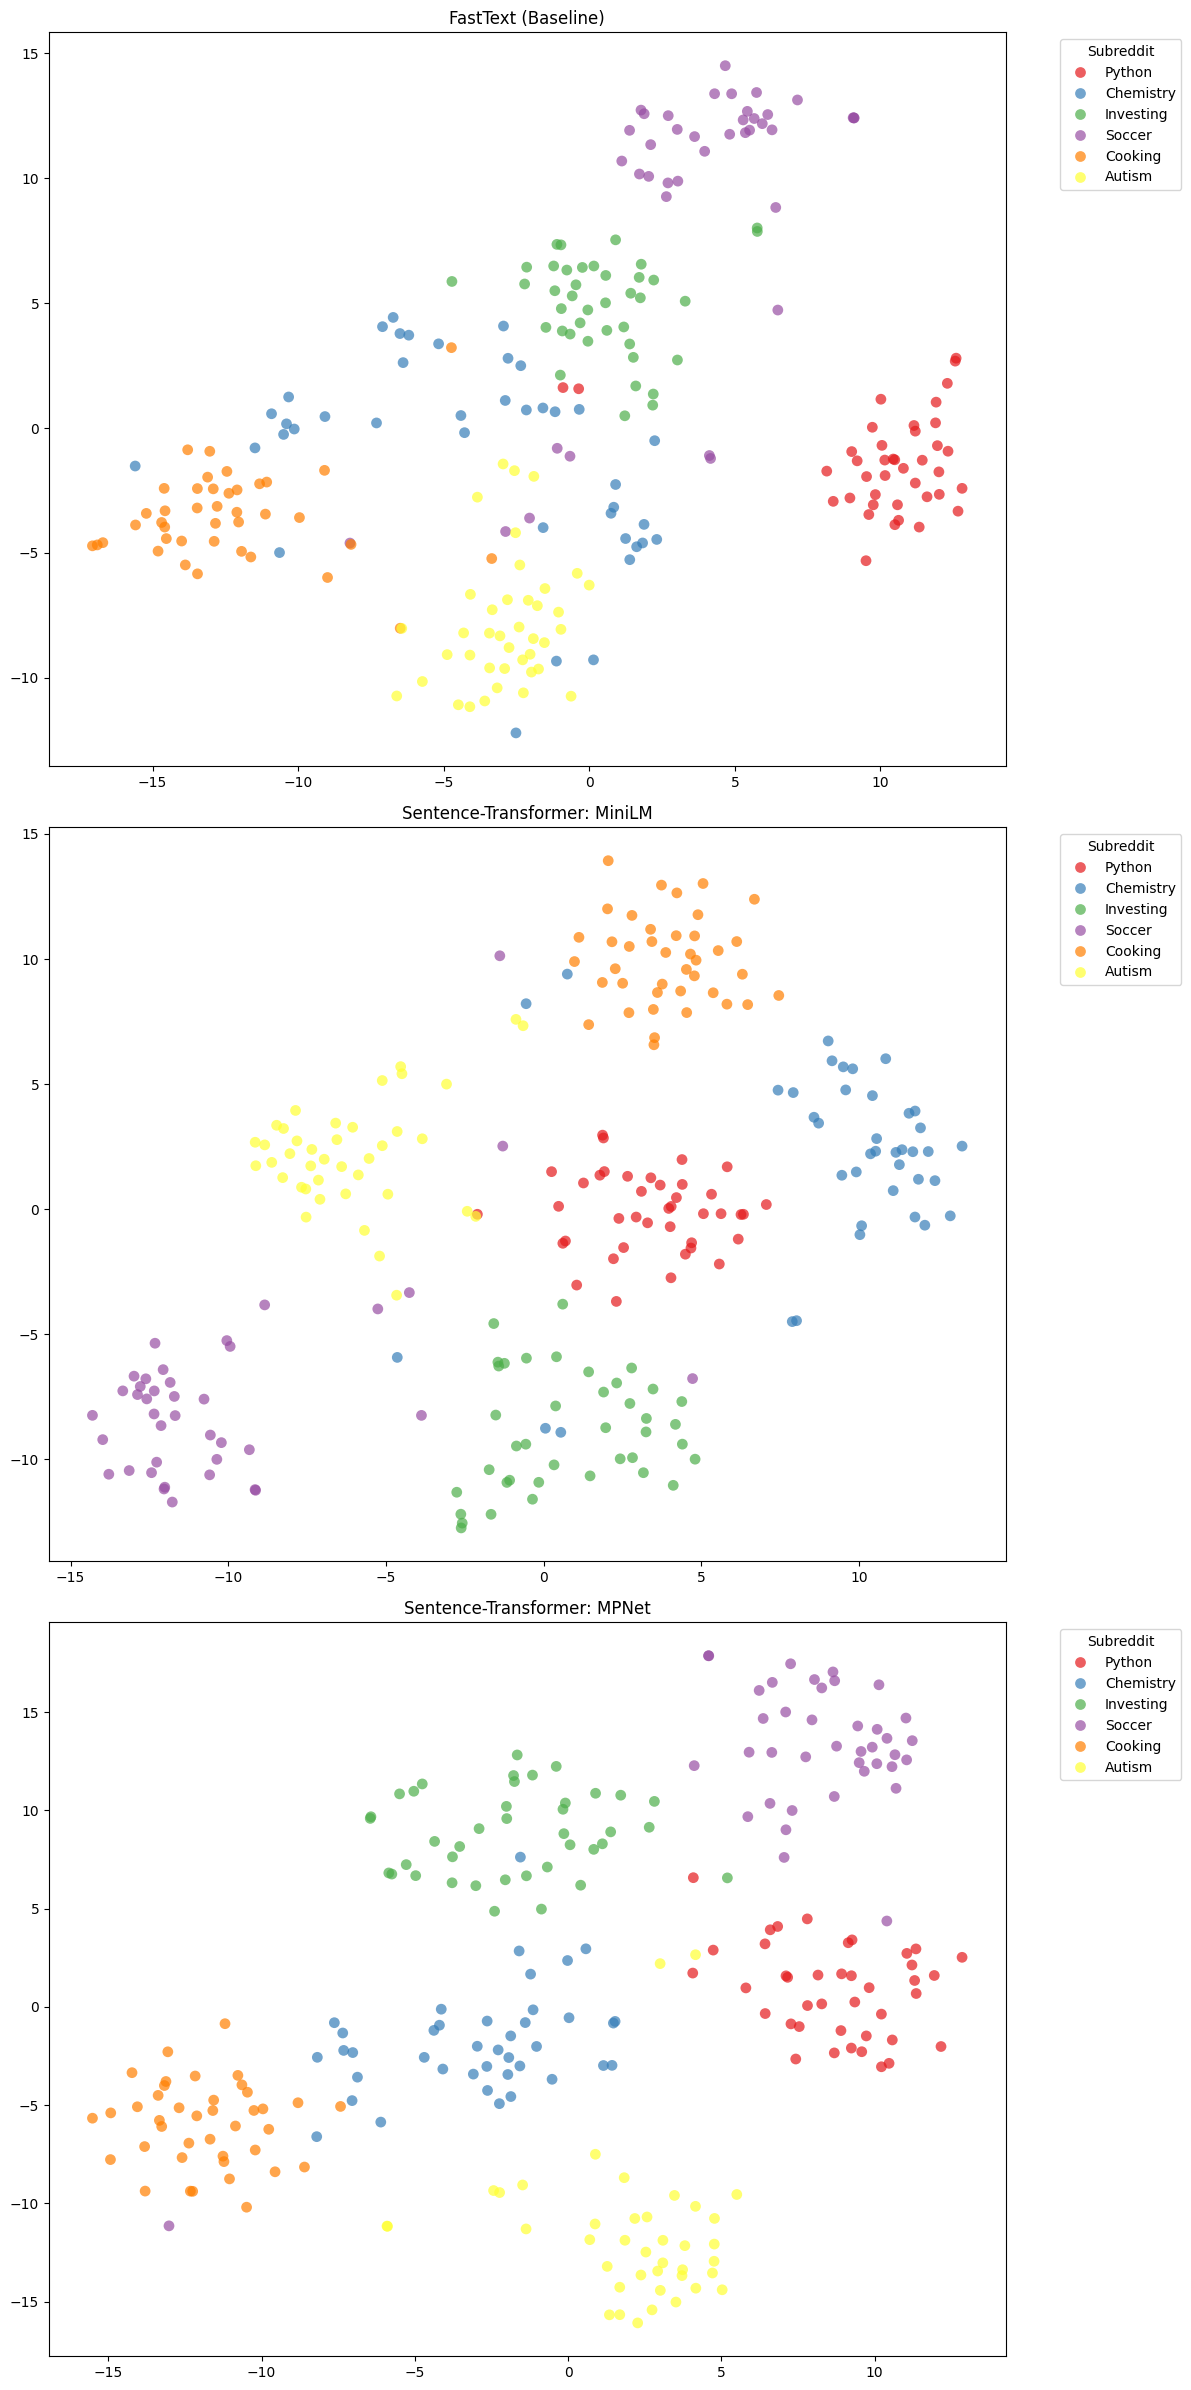

In [ ]:
def plot_tsne_comparison(embeddings, title, subplot_ax):
    # PCA previo para reducir dimensiones y ruido
    pca_result = PCA(n_components=min(50, len(embeddings)), random_state=42).fit_transform(embeddings)
    # t-SNE para visualización 2D
    tsne_result = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(pca_result)

    sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=df_hilos['subreddit'],
                    palette='Set1', s=60, alpha=0.7, ax=subplot_ax, edgecolor='none')
    subplot_ax.set_title(title)
    subplot_ax.legend(title='Subreddit', bbox_to_anchor=(1.05, 1), loc='upper left')

fig, axes = plt.subplots(3, 1, figsize=(12, 24))

plot_tsne_comparison(X_embeddings, "FastText (Baseline)", axes[0])
plot_tsne_comparison(X_emb_mini, "Sentence-Transformer: MiniLM", axes[1])
plot_tsne_comparison(X_emb_mpnet, "Sentence-Transformer: MPNet", axes[2])

plt.tight_layout()
plt.show()

De igual forma que con el mapa de calor, volvemos a mostrar el scatterplot del modelo de FastText para realizar la comparación de mejor forma.

**Calidad del Clustering y Sensibilidad Semántica**

**FastText (Baseline):** Aunque logra separar grupos, existe una dispersión notable, especialmente en Chemistry. Esto se debe a que, tal y como hemos mencionado más arriba, FastText se basa en la media de vectores de palabras (y subpalabras); si dos hilos comparten términos técnicos comunes pero tratan temas distintos, el modelo los acerca erróneamente.

**Sentence-Transformers (MiniLM y MPNet):** Se observa una clusterización mucho más definida. MPNet, al tener 768 dimensiones, ofrece la separación más limpia. Los modelos basados en Transformers entienden el orden de las palabras y el contexto global.